<a href="https://colab.research.google.com/github/metel152/Volans-tarkvara/blob/Programmid-graafikute-jaoks/Hea_tulemus_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


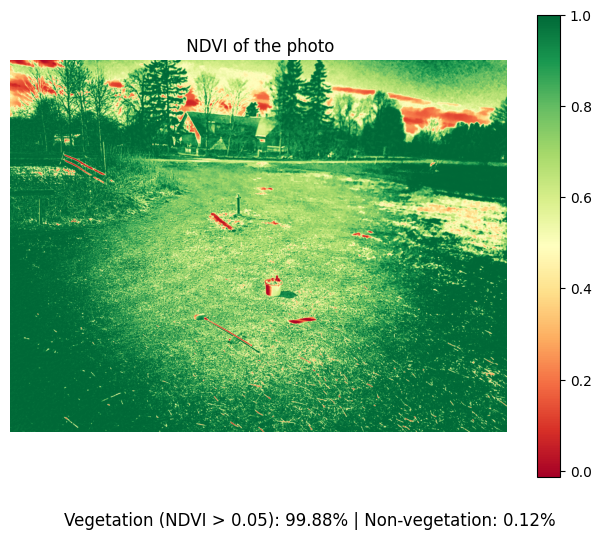

In [11]:
from google.colab import drive
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. Mount Google Drive ---
drive.mount('/content/drive')

# --- 2. Load image ---
path = '/content/drive/MyDrive/Volans_camera/test21.jpg'
pilt = cv2.imread(path)

if pilt is None:
    raise ValueError("Pilti ei leitud – kontrolli failiteed")

# --- 3. Channels (OpenCV = BGR) ---
NIR = pilt[:, :, 2].astype(float)   # red channel used as NIR proxy
RED = pilt[:, :, 1].astype(float)   # green channel used as RED proxy

# --- 4. NDVI calculation ---
ndvi = (NIR - RED) / (NIR + RED + 1e-10)

# --- 5. Classification (ONLY for statistics) ---
vegetation = ndvi > 0.05
non_vegetation = ndvi <= 0.05

# --- 6. Pixel statistics ---
total_pixels = ndvi.size

red_pixels = np.sum(vegetation)
green_pixels = np.sum(non_vegetation)

red_percent = (red_pixels / total_pixels) * 100
green_percent = (green_pixels / total_pixels) * 100

# --- 7. Display ONLY NDVI image ---
plt.figure(figsize=(8, 6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar()
plt.title(" NDVI of the photo")
plt.axis('off')

# --- 8. Add percentages under image ---
plt.figtext(
    0.5, 0.03,
        f"Vegetation (NDVI > 0.05): {red_percent:.2f}% | Non-vegetation: {green_percent:.2f}%",
            ha="center",
                fontsize=12
                )

plt.show()